In [1]:
import pandas as pd

df = pd.read_csv('customer_churn.csv')

df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    object 
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    object 
 7   Location         900 non-null    object 
 8   Company          900 non-null    object 
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 70.4+ KB


In [3]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,0.166667
std,6.127560,2408.644532,0.499921,1.274449,1.764836,0.372885
min,22.000000,100.000000,0.000000,1.000000,3.000000,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,1.000000


In [4]:
df.isnull().sum()

,0
Names,0
Age,0
Total_Purchase,0
Account_Manager,0
Years,0
Num_Sites,0
Onboard_date,0
Location,0
Company,0
Churn,0


In [5]:
df['Churn'].value_counts()

,count
Churn,
0,750
1,150


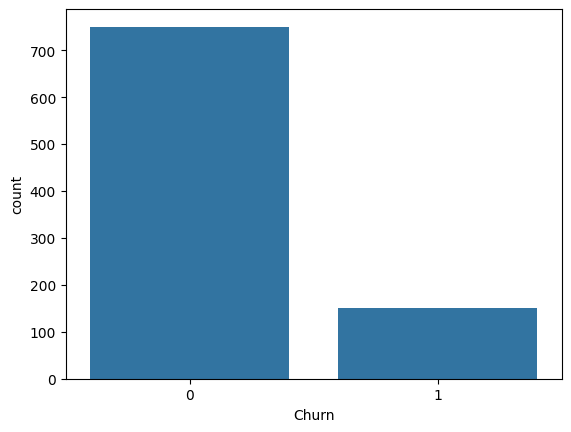

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.show()

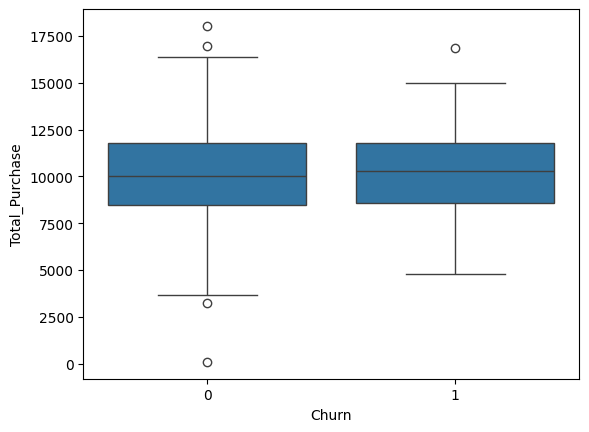

In [7]:
sns.boxplot(x='Churn', y='Total_Purchase', data=df)
plt.show()

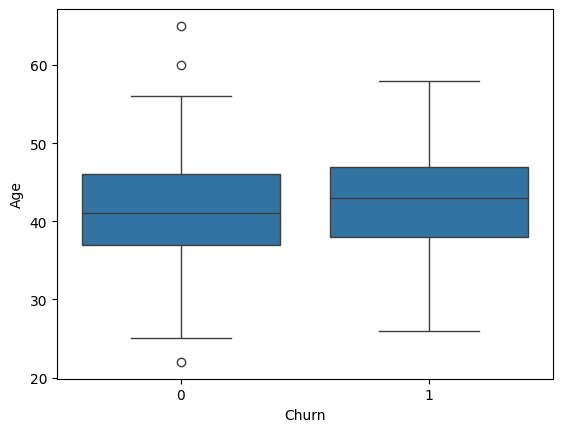

In [8]:
sns.boxplot(x='Churn', y='Age', data=df)
plt.show()

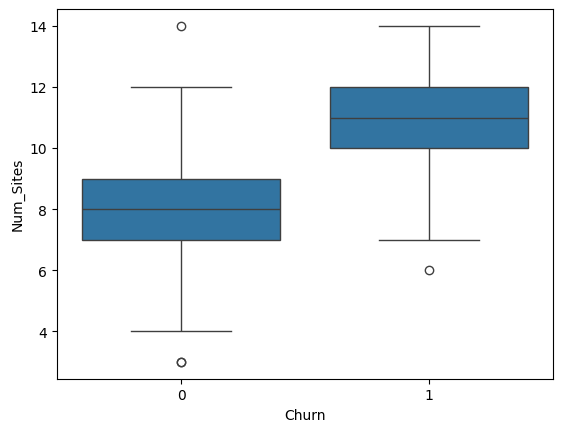

In [9]:
sns.boxplot(x='Churn', y='Num_Sites', data=df)
plt.show()

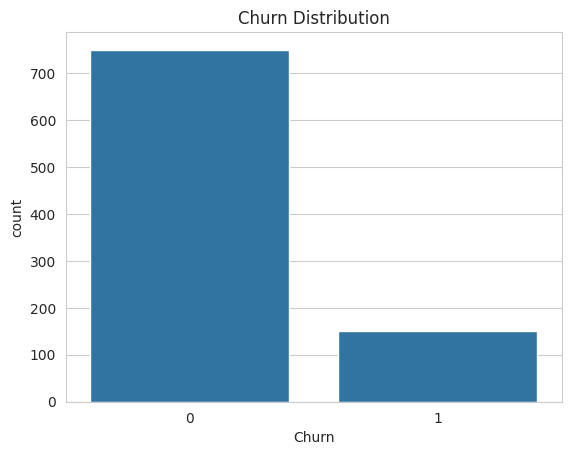

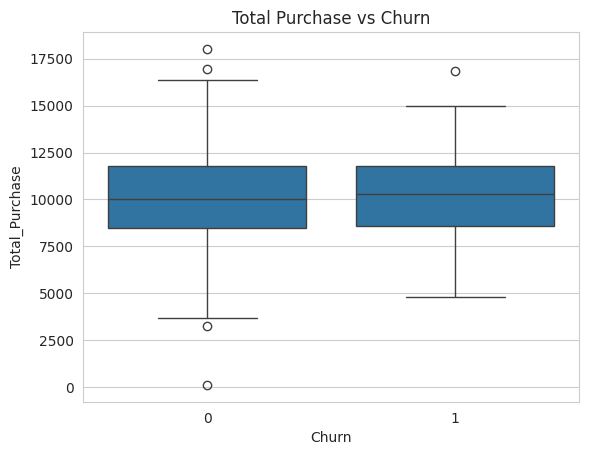

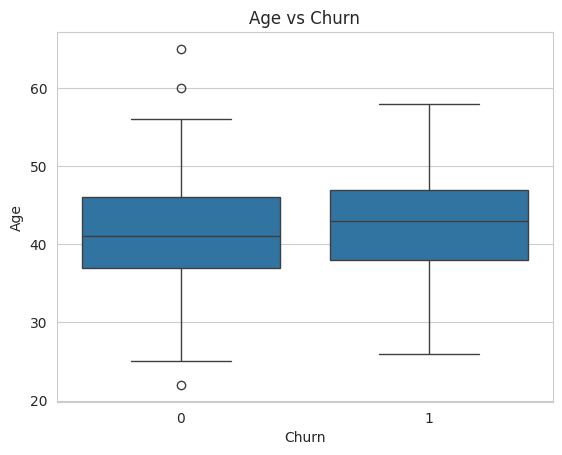

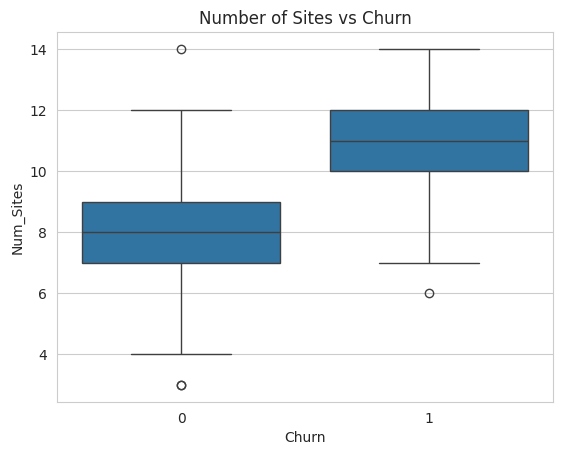

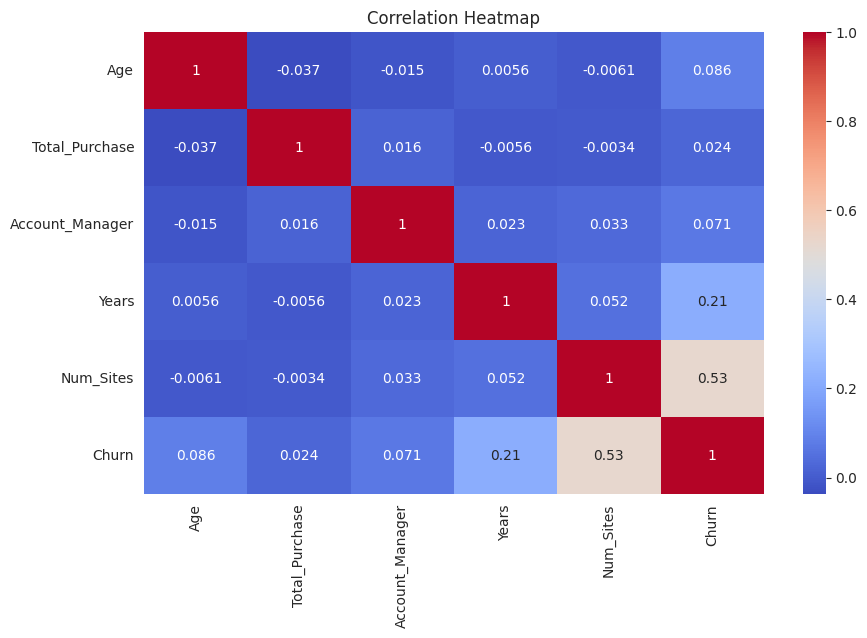

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# style
sns.set_style("whitegrid")

# 1. Churn distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

# 2. Total Purchase vs Churn
sns.boxplot(x='Churn', y='Total_Purchase', data=df)
plt.title("Total Purchase vs Churn")
plt.show()

# 3. Age vs Churn
sns.boxplot(x='Churn', y='Age', data=df)
plt.title("Age vs Churn")
plt.show()

# 4. Number of Sites vs Churn
sns.boxplot(x='Churn', y='Num_Sites', data=df)
plt.title("Number of Sites vs Churn")
plt.show()

# 5. Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [11]:
# ===== ENCODING  =====

# drop columns
df = df.drop(['Name', 'Onboard_date'], axis=1, errors='ignore')

# convert ALL object columns
df = pd.get_dummies(df, columns=df.select_dtypes(include=['object']).columns, drop_first=True)

# checking again
print(df.select_dtypes(include=['object']).columns)

Index([], dtype='object')


In [12]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Churn', axis=1)
y = df['Churn']

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# ALL features
X = df.drop('Churn', axis=1)
y = df['Churn']

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# accuracy
print(model.score(X_test, y_test))

0.9074074074074074


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))

[[219   8]
 [ 17  26]]
